In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import os
import sqlite3
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
base_path = '/content/drive/MyDrive/Instacart Customer Purchase Behavior and Sales Analysis/Cleaned_Data'

In [4]:
orders = pd.read_csv(os.path.join(base_path, 'Datasetscleaned_orders.csv'))

products = pd.read_csv(os.path.join(base_path, 'Datasetscleaned_products.csv'))

prior = pd.read_csv(os.path.join(base_path, 'Datasetscleaned_prior.csv'))

# Take only 20% sample
prior = prior.sample(frac=0.2, random_state=42)

train = pd.read_csv(os.path.join(base_path, 'Datasetscleaned_train.csv'))

In [5]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,0.0
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [6]:
products.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


In [7]:
prior.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
29481110,3109255,34099,16,0,Crushed Red Chili Pepper,104,13,spices seasonings,pantry
2852353,301098,41950,5,0,Organic Tomato Cluster,83,4,fresh vegetables,produce
11194500,1181866,45066,8,0,Honeycrisp Apple,24,4,fresh fruits,produce
15909397,1678630,8859,2,1,Natural Spring Water,115,7,water seltzer sparkling water,beverages
6101870,644090,24781,2,0,"PODS Laundry Detergent, Ocean Mist Designed fo...",75,17,laundry,household


In [8]:
orders.shape

(3421083, 7)

In [9]:
products.shape

(49688, 6)

In [10]:
prior.shape

(6486898, 9)

Orders by Day

In [11]:
orders_by_day = orders['order_dow'].value_counts().sort_index()

orders_by_day

,count
order_dow,
0,600905
1,587478
2,467260
3,436972
4,426339
5,453368
6,448761


Orders by Day Chart

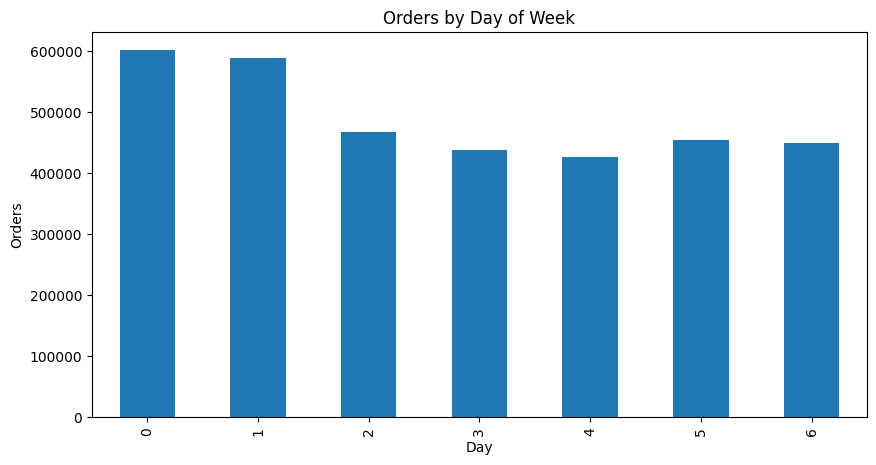

In [12]:
plt.figure(figsize=(10,5))

orders_by_day.plot(kind='bar')

plt.title('Orders by Day of Week')

plt.xlabel('Day')

plt.ylabel('Orders')

plt.show()

Top Departments

In [13]:
top_departments = prior['department'].value_counts().head(10)

top_departments

,count
department,
produce,1895558
dairy eggs,1083005
snacks,577217
beverages,538807
frozen,446746
pantry,374691
bakery,234665
canned goods,213829
deli,211022


Department Chart

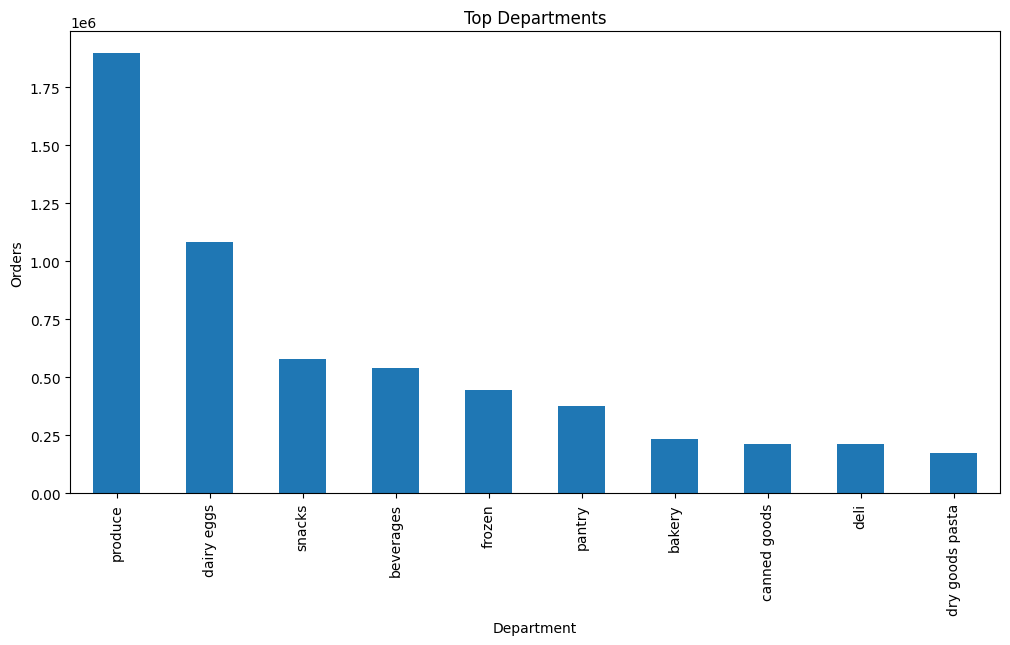

In [14]:
plt.figure(figsize=(12,6))

top_departments.plot(kind='bar')

plt.title('Top Departments')

plt.xlabel('Department')

plt.ylabel('Orders')

plt.show()

Top Products

In [15]:
top_products = prior['product_name'].value_counts().head(10)

top_products

,count
product_name,
Banana,94443
Bag of Organic Bananas,75986
Organic Strawberries,53058
Organic Baby Spinach,48272
Organic Hass Avocado,42643
Organic Avocado,35360
Large Lemon,30603
Strawberries,28505
Limes,28200


Product Chart

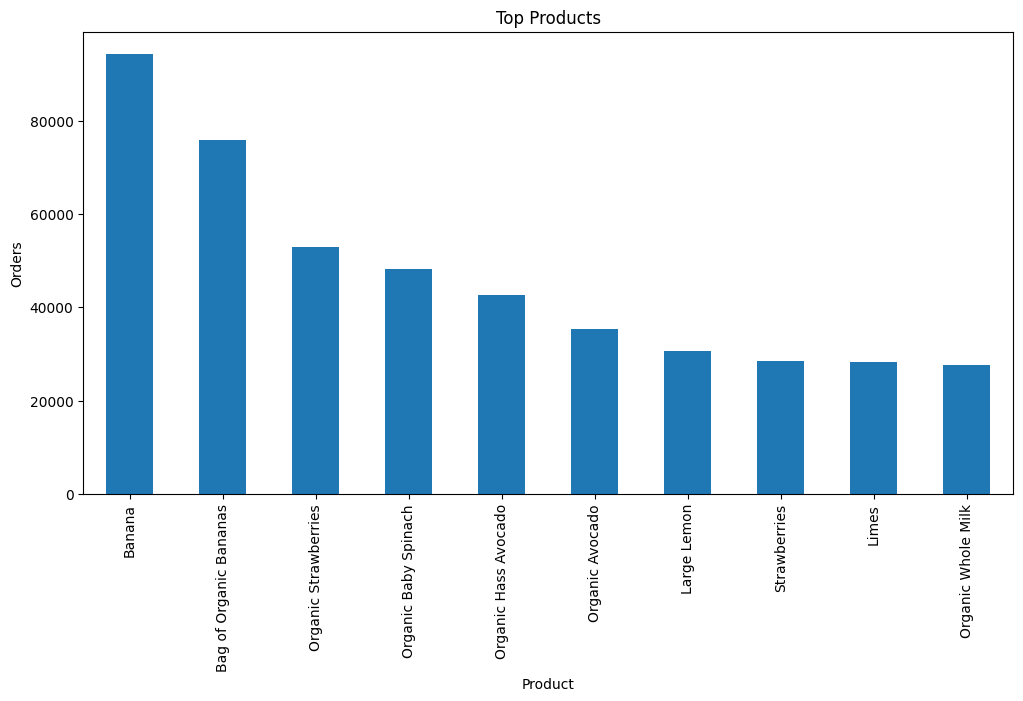

In [16]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top Products')

plt.xlabel('Product')

plt.ylabel('Orders')

plt.show()

Reorder Rate

In [17]:
reorder_rate = prior['reordered'].mean() * 100

print(reorder_rate)

58.97270159018995


Most Reordered Products

In [18]:
top_reordered = prior[prior['reordered'] == 1]['product_name'].value_counts().head(10)

top_reordered

,count
product_name,
Banana,79456
Bag of Organic Bananas,63249
Organic Strawberries,41349
Organic Baby Spinach,37281
Organic Hass Avocado,33899
Organic Avocado,26734
Organic Whole Milk,22932
Large Lemon,21326
Organic Raspberries,20957


Basket Size Analysis

In [19]:
basket_size = prior.groupby('order_id')['product_id'].count()

basket_size.head()

,product_id
order_id,
2,1
3,1
4,2
5,6
7,1


Average Basket Size

In [20]:
basket_size.mean()

np.float64(2.6245987885467454)

Basket Histogram

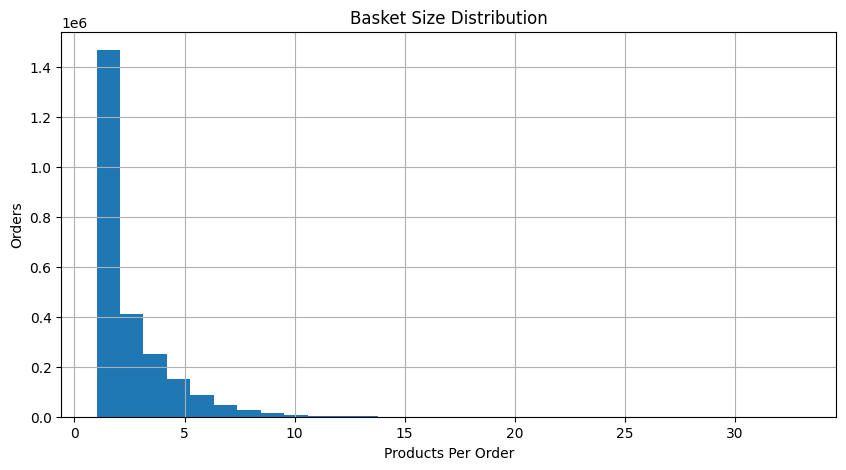

In [21]:
plt.figure(figsize=(10,5))

basket_size.hist(bins=30)

plt.title('Basket Size Distribution')

plt.xlabel('Products Per Order')

plt.ylabel('Orders')

plt.show()

Customer Order Frequency

In [22]:
customer_orders = orders.groupby('user_id')['order_number'].max()

customer_orders.head()

,order_number
user_id,
1,11
2,15
3,13
4,6
5,5


Customer Frequency Chart

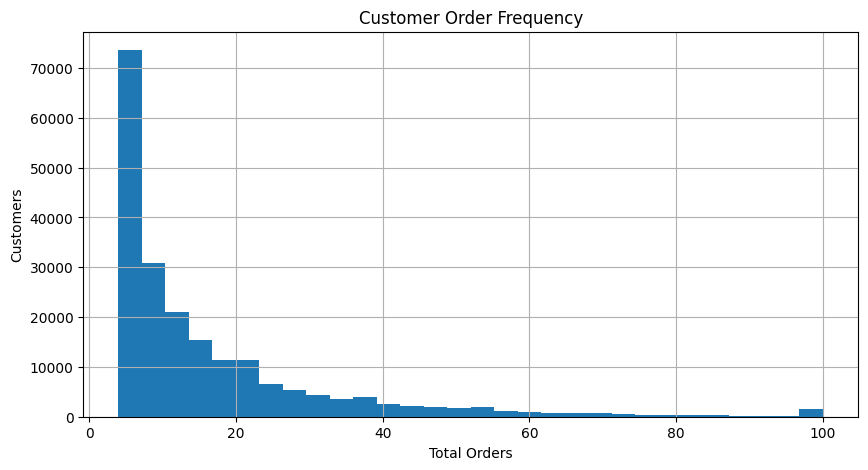

In [23]:
plt.figure(figsize=(10,5))

customer_orders.hist(bins=30)

plt.title('Customer Order Frequency')

plt.xlabel('Total Orders')

plt.ylabel('Customers')

plt.show()

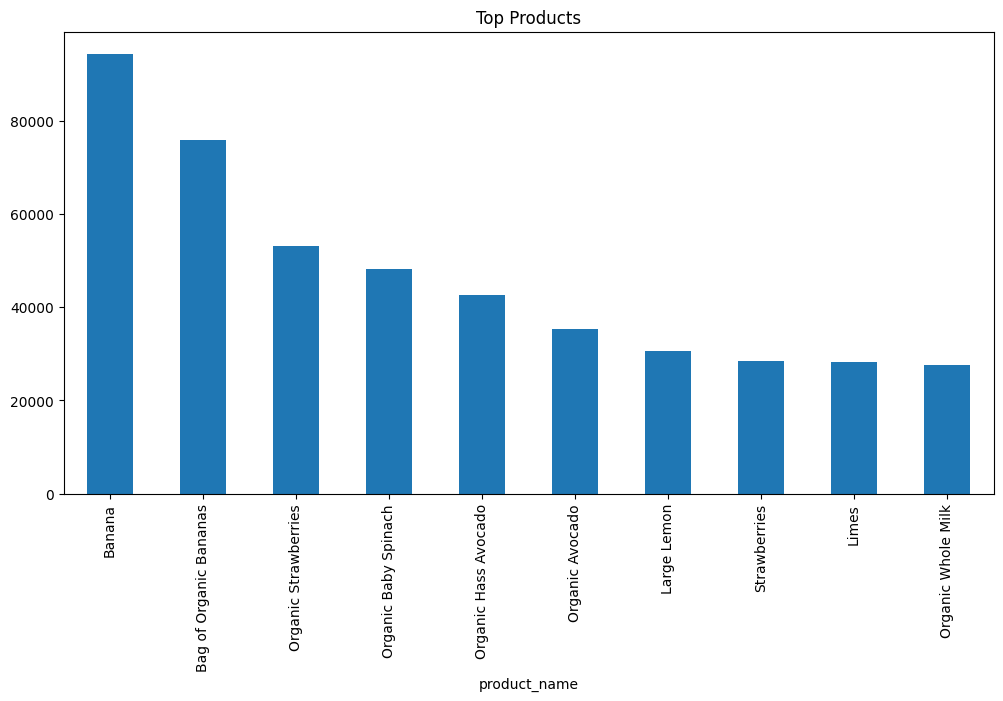

In [24]:
plt.figure(figsize=(12,6))

top_products.plot(kind='bar')

plt.title('Top Products')

plt.savefig('/content/drive/MyDrive/Instacart Customer Purchase Behavior and Sales Analysis/Screenshots/top_products.png')

plt.show()

importing  sql

In [25]:
import sqlite3

In [26]:
conn = sqlite3.connect(':memory:')

In [29]:
orders.to_sql('orders', conn, index=False, if_exists='replace')

products.to_sql('products', conn, index=False, if_exists='replace')

prior_sql = prior.sample(frac=0.05, random_state=42)

prior_sql.to_sql('prior', conn, index=False, if_exists='replace')

train_sql = train.sample(frac=0.1, random_state=42)

train_sql.to_sql('train', conn, index=False, if_exists='replace')

138462

In [30]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,orders
1,products
2,prior
3,train


Top 10 products

In [31]:
query1 = """
SELECT product_id, COUNT(*) AS total_orders
FROM prior
GROUP BY product_id
ORDER BY total_orders DESC
LIMIT 10;
"""
top_products_sql = pd.read_sql(query1, conn)
top_products_sql

,product_id,total_orders
0,24852,4753
1,13176,3856
2,21137,2705
3,21903,2419
4,47209,2172
5,47766,1766
6,47626,1567
7,26209,1426
8,16797,1426
9,27966,1384


product names to top products

In [32]:
top_products_sql = top_products_sql.merge(
    products[['product_id', 'product_name']],
    on='product_id',
    how='left'
)

top_products_sql

,product_id,total_orders,product_name
0,24852,4753,Banana
1,13176,3856,Bag of Organic Bananas
2,21137,2705,Organic Strawberries
3,21903,2419,Organic Baby Spinach
4,47209,2172,Organic Hass Avocado
5,47766,1766,Organic Avocado
6,47626,1567,Large Lemon
7,26209,1426,Limes
8,16797,1426,Strawberries
9,27966,1384,Organic Raspberries


Top 10 product names directly

In [33]:
query2 = """
SELECT p.product_name, COUNT(*) AS total_orders
FROM prior pr
JOIN products p ON pr.product_id = p.product_id
GROUP BY p.product_name
ORDER BY total_orders DESC
LIMIT 10;
"""
pd.read_sql(query2, conn)

,product_name,total_orders
0,Banana,4753
1,Bag of Organic Bananas,3856
2,Organic Strawberries,2705
3,Organic Baby Spinach,2419
4,Organic Hass Avocado,2172
5,Organic Avocado,1766
6,Large Lemon,1567
7,Strawberries,1426
8,Limes,1426
9,Organic Raspberries,1384


Orders by day of week

In [35]:
query3 = """
SELECT order_dow, COUNT(*) AS total_orders
FROM orders
GROUP BY order_dow
ORDER BY order_dow;
"""
orders_day_sql = pd.read_sql(query3, conn)
orders_day_sql

,order_dow,total_orders
0,0,600905
1,1,587478
2,2,467260
3,3,436972
4,4,426339
5,5,453368
6,6,448761


Orders by hour

In [34]:
query4 = """
SELECT order_hour_of_day, COUNT(*) AS total_orders
FROM orders
GROUP BY order_hour_of_day
ORDER BY order_hour_of_day;
"""
orders_hour_sql = pd.read_sql(query4, conn)
orders_hour_sql

,order_hour_of_day,total_orders
0,0,22758
1,1,12398
2,2,7539
3,3,5474
4,4,5527
5,5,9569
6,6,30529
7,7,91868
8,8,178201
9,9,257812


Reorder analysis

In [36]:
query5 = """
SELECT reordered, COUNT(*) AS total_count
FROM prior
GROUP BY reordered;
"""
reorder_sql = pd.read_sql(query5, conn)
reorder_sql

,reordered,total_count
0,0,132835
1,1,191510


Top reordered products

In [37]:
query6 = """
SELECT p.product_name, COUNT(*) AS reorder_count
FROM prior pr
JOIN products p ON pr.product_id = p.product_id
WHERE pr.reordered = 1
GROUP BY p.product_name
ORDER BY reorder_count DESC
LIMIT 10;
"""
top_reordered_sql = pd.read_sql(query6, conn)
top_reordered_sql

,product_name,reorder_count
0,Banana,3997
1,Bag of Organic Bananas,3220
2,Organic Strawberries,2107
3,Organic Baby Spinach,1882
4,Organic Hass Avocado,1712
5,Organic Avocado,1332
6,Organic Whole Milk,1153
7,Large Lemon,1105
8,Organic Raspberries,1060
9,Strawberries,988


Top departments

In [38]:
query7 = """
SELECT p.department_id, COUNT(*) AS total_orders
FROM prior pr
JOIN products p ON pr.product_id = p.product_id
GROUP BY p.department_id
ORDER BY total_orders DESC
LIMIT 10;
"""
top_departments_sql = pd.read_sql(query7, conn)
top_departments_sql

,department_id,total_orders
0,4,94941
1,16,54185
2,19,28683
3,7,27128
4,1,22461
5,13,18687
6,3,11940
7,20,10548
8,15,10501
9,9,8677


Saved SQL outputs

In [40]:
output_path = '/content/drive/MyDrive/Instacart Customer Purchase Behavior and Sales Analysis/SQL_Output'
import os
os.makedirs(output_path, exist_ok=True)

top_products_sql.to_csv(os.path.join(output_path, 'top_products_sql.csv'), index=False)
orders_day_sql.to_csv(os.path.join(output_path, 'orders_day_sql.csv'), index=False)
orders_hour_sql.to_csv(os.path.join(output_path, 'orders_hour_sql.csv'), index=False)
reorder_sql.to_csv(os.path.join(output_path, 'reorder_sql.csv'), index=False)
top_reordered_sql.to_csv(os.path.join(output_path, 'top_reordered_sql.csv'), index=False)